<a href="https://colab.research.google.com/github/Lavesh789/Sales_forecasting/blob/main/Sales%20Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [263]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
file_path = "sales_forecasting_master_dataset 2.xlsx"
df = pd.read_excel(file_path)

In [264]:
df.head()

,Row_ID,Date,Product_ID,Product_Name,Category,Store_ID,Store_Location,Units_Sold,Price,Discount_Percentage,...,Holiday_Name,Is_Weekend,Season,Weather,Local_Event_Flag,Competitor_Price,Economic_Indicator,Sales_Channel,Customer_Segment,Marketing_Spend
0,1,2024-01-01,P002,Bluetooth Speaker,Electronics,S01,Chennai,58,3759.44,0,...,New Year,0,Winter,Sunny,1,3448.86,101.33,Online,Retail,109.32
1,2,2024-01-02,P001,Wireless Mouse,Electronics,S02,Bengaluru,0,3636.89,15,...,NaN,0,Winter,Stormy,0,3599.95,99.17,Online,Retail,7132.32
2,3,2024-01-03,P006,Running Shoes,Apparel,S03,Mumbai,91,946.30,20,...,NaN,0,Winter,Sunny,0,923.58,100.38,In-Store,Wholesale,3012.95
3,4,2024-01-04,P001,Wireless Mouse,Electronics,S04,Delhi,57,2773.89,5,...,NaN,0,Winter,Clear,0,2956.64,104.28,In-Store,Wholesale,2326.74
4,5,2024-01-05,P002,Bluetooth Speaker,Electronics,S01,Chennai,59,3374.06,20,...,NaN,0,Winter,Sunny,0,3621.37,100.70,In-Store,Wholesale,8424.05


In [265]:
df.tail()

,Row_ID,Date,Product_ID,Product_Name,Category,Store_ID,Store_Location,Units_Sold,Price,Discount_Percentage,...,Holiday_Name,Is_Weekend,Season,Weather,Local_Event_Flag,Competitor_Price,Economic_Indicator,Sales_Channel,Customer_Segment,Marketing_Spend
725,726,2025-12-26,P003,Office Chair,Furniture,S04,Delhi,52,4138.05,20,...,NaN,0,Winter,Rainy,0,4226.59,97.66,Online,Wholesale,7543.74
726,727,2025-12-27,P003,Office Chair,Furniture,S01,Chennai,26,3422.68,0,...,NaN,1,Winter,Stormy,0,3202.22,105.72,Wholesale,Wholesale,108.08
727,728,2025-12-28,P001,Wireless Mouse,Electronics,S01,Chennai,57,2074.97,0,...,NaN,1,Winter,Clear,0,1887.67,100.66,Online,Retail,4059.12
728,729,2025-12-29,P004,Notebook Pack,Stationery,S02,Bengaluru,62,638.65,5,...,NaN,0,Winter,Sunny,0,679.59,105.20,Online,Retail,9608.08
729,730,2025-12-30,P002,Bluetooth Speaker,Electronics,S02,Bengaluru,0,3675.26,0,...,NaN,0,Winter,Sunny,0,3544.92,104.40,Wholesale,Retail,9376.11


In [266]:
df.shape

(730, 27)

In [267]:
df.columns

Index(['Row_ID', 'Date', 'Product_ID', 'Product_Name', 'Category', 'Store_ID',
       'Store_Location', 'Units_Sold', 'Price', 'Discount_Percentage',
       'Revenue', 'Promotion_Flag', 'Stock_Availability', 'Day_of_Week',
       'Month', 'Quarter', 'Holiday_Flag', 'Holiday_Name', 'Is_Weekend',
       'Season', 'Weather', 'Local_Event_Flag', 'Competitor_Price',
       'Economic_Indicator', 'Sales_Channel', 'Customer_Segment',
       'Marketing_Spend'],
      dtype='object')

In [268]:
df.dtypes

,0
Row_ID,int64
Date,object
Product_ID,object
Product_Name,object
Category,object
Store_ID,object
Store_Location,object
Units_Sold,int64
Price,float64
Discount_Percentage,int64


Converting Date

In [269]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

,0
Row_ID,int64
Date,datetime64[ns]
Product_ID,object
Product_Name,object
Category,object
Store_ID,object
Store_Location,object
Units_Sold,int64
Price,float64
Discount_Percentage,int64


In [270]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Row_ID               730 non-null    int64         
 1   Date                 730 non-null    datetime64[ns]
 2   Product_ID           730 non-null    object        
 3   Product_Name         730 non-null    object        
 4   Category             730 non-null    object        
 5   Store_ID             730 non-null    object        
 6   Store_Location       730 non-null    object        
 7   Units_Sold           730 non-null    int64         
 8   Price                730 non-null    float64       
 9   Discount_Percentage  730 non-null    int64         
 10  Revenue              730 non-null    float64       
 11  Promotion_Flag       730 non-null    int64         
 12  Stock_Availability   730 non-null    int64         
 13  Day_of_Week          730 non-null  

In [271]:
df.isnull().sum()

,0
Row_ID,0
Date,0
Product_ID,0
Product_Name,0
Category,0
Store_ID,0
Store_Location,0
Units_Sold,0
Price,0
Discount_Percentage,0


In [272]:
df.duplicated().sum()

np.int64(0)

In [273]:
df['Row_ID'].duplicated().sum()

np.int64(0)

In [274]:
df['Date'].duplicated().sum()

np.int64(0)

Statistical Summary

In [275]:
df.describe()

,Row_ID,Date,Units_Sold,Price,Discount_Percentage,Revenue,Promotion_Flag,Stock_Availability,Holiday_Flag,Is_Weekend,Local_Event_Flag,Competitor_Price,Economic_Indicator,Marketing_Spend
count,730.000000,730,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2024-12-30 12:00:00,42.153425,2557.936041,7.595890,85193.486849,0.704110,0.793151,0.009589,0.284932,0.213699,2560.415822,102.847945,3898.153452
min,1.000000,2024-01-01 00:00:00,0.000000,204.810000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.350000,95.040000,2.420000
25%,183.250000,2024-07-01 06:00:00,16.000000,1253.662500,0.000000,27826.057500,0.000000,1.000000,0.000000,0.000000,0.000000,1276.320000,99.162500,444.120000
50%,365.500000,2024-12-30 12:00:00,44.000000,2518.940000,5.000000,73474.685000,1.000000,1.000000,0.000000,0.000000,0.000000,2526.305000,103.205000,3580.140000
75%,547.750000,2025-06-30 18:00:00,64.000000,3759.057500,15.000000,134810.962500,1.000000,1.000000,0.000000,1.000000,0.000000,3746.552500,106.440000,6634.722500
max,730.000000,2025-12-30 00:00:00,118.000000,4987.790000,20.000000,282047.830000,1.000000,1.000000,1.000000,1.000000,1.000000,5321.850000,109.970000,9973.030000
std,210.877136,NaN,29.115559,1403.598221,7.658323,66840.589434,0.456755,0.405324,0.097520,0.451691,0.410198,1415.881836,4.350497,3254.564368


In [276]:
df[['Units_Sold','Price','Discount_Percentage','Revenue','Stock_Availability','Competitor_Price','Economic_Indicator','Marketing_Spend']].describe()

,Units_Sold,Price,Discount_Percentage,Revenue,Stock_Availability,Competitor_Price,Economic_Indicator,Marketing_Spend
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,42.153425,2557.936041,7.595890,85193.486849,0.793151,2560.415822,102.847945,3898.153452
std,29.115559,1403.598221,7.658323,66840.589434,0.405324,1415.881836,4.350497,3254.564368
min,0.000000,204.810000,0.000000,0.000000,0.000000,184.350000,95.040000,2.420000
25%,16.000000,1253.662500,0.000000,27826.057500,1.000000,1276.320000,99.162500,444.120000
50%,44.000000,2518.940000,5.000000,73474.685000,1.000000,2526.305000,103.205000,3580.140000
75%,64.000000,3759.057500,15.000000,134810.962500,1.000000,3746.552500,106.440000,6634.722500
max,118.000000,4987.790000,20.000000,282047.830000,1.000000,5321.850000,109.970000,9973.030000


Separate Numerical and Categorical Variables

In [277]:
from pandas.core.tools import numeric
numeric_cols = df.select_dtypes(include=np.number).columns
print(numeric_cols)

Index(['Row_ID', 'Units_Sold', 'Price', 'Discount_Percentage', 'Revenue',
       'Promotion_Flag', 'Stock_Availability', 'Holiday_Flag', 'Is_Weekend',
       'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator',
       'Marketing_Spend'],
      dtype='object')


In [278]:
Categorical_cols = df.select_dtypes(include='object').columns
print(Categorical_cols)

Index(['Product_ID', 'Product_Name', 'Category', 'Store_ID', 'Store_Location',
       'Day_of_Week', 'Month', 'Quarter', 'Holiday_Name', 'Season', 'Weather',
       'Sales_Channel', 'Customer_Segment'],
      dtype='object')


Analyze target variable

In [279]:
df['Units_Sold'].describe()

,Units_Sold
count,730.000000
mean,42.153425
std,29.115559
min,0.000000
25%,16.000000
50%,44.000000
75%,64.000000
max,118.000000


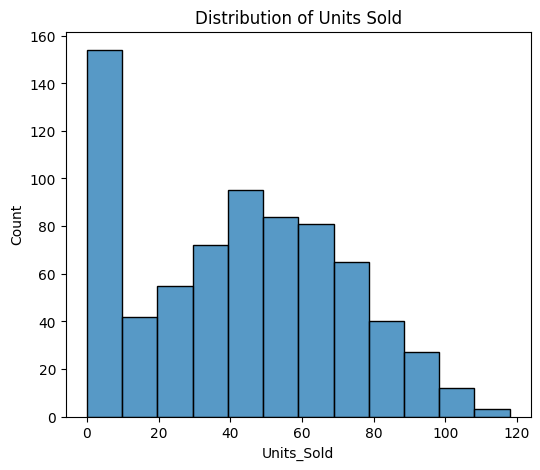

In [280]:
plt.figure(figsize=(6,5))
sns.histplot(df['Units_Sold'])
plt.title('Distribution of Units Sold')
plt.xlabel('Units_Sold')
plt.show()

Outlier Detection

In [281]:
outlier_summary = {}
for column in numeric_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[
        (df[column] < lower_limit) |(df[column] > upper_limit)
    ]

    outlier_summary[column] = len(outliers)
    print(column,"-",len(outliers))


Row_ID - 0
Units_Sold - 0
Price - 0
Discount_Percentage - 0
Revenue - 0
Promotion_Flag - 0
Stock_Availability - 151
Holiday_Flag - 7
Is_Weekend - 0
Local_Event_Flag - 156
Competitor_Price - 0
Economic_Indicator - 0
Marketing_Spend - 0


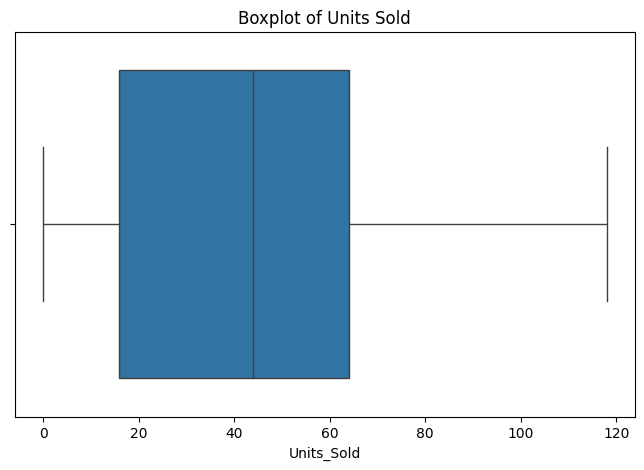

In [282]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Units_Sold'])

plt.title('Boxplot of Units Sold')
plt.show()

Analyze sales over time

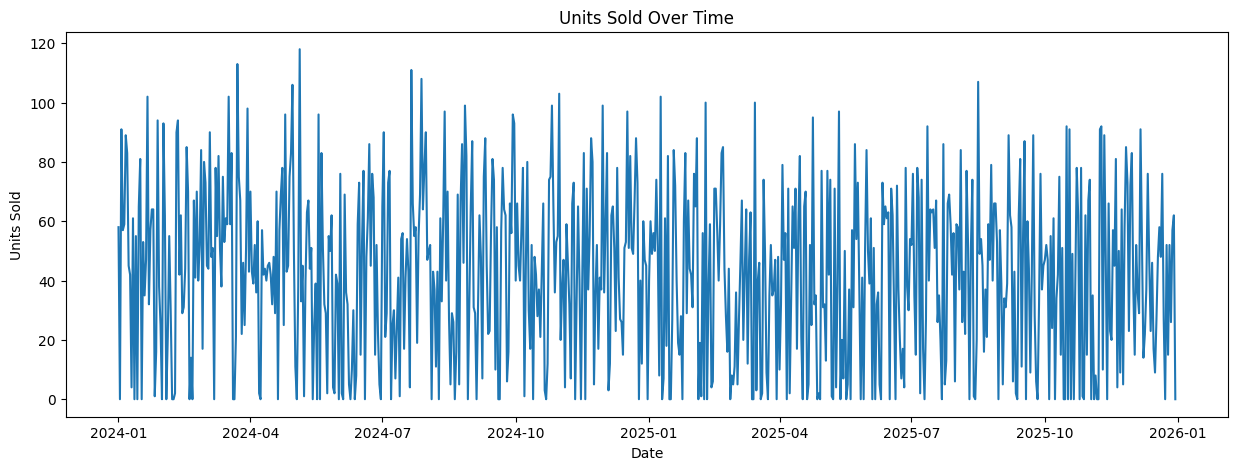

In [283]:
df = df.sort_values('Date')
plt.figure(figsize=(15,5))
plt.plot(df['Date'], df['Units_Sold'])
plt.title('Units Sold Over Time')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.show()

Daily Revenue trend

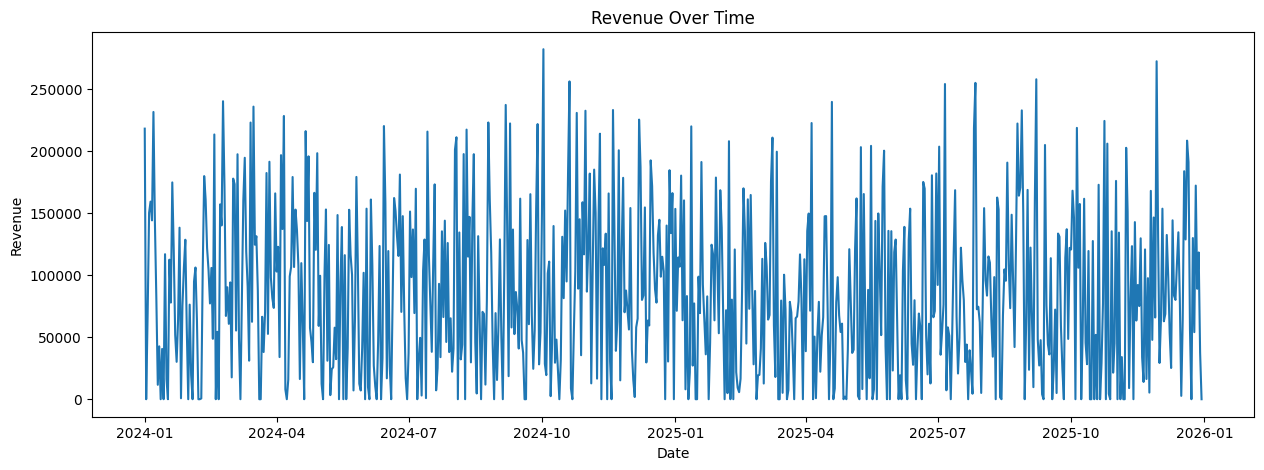

In [284]:
plt.figure(figsize=(15,5))
plt.plot(df['Date'], df['Revenue'])
plt.title('Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

Monthly sales analysis

In [285]:
monthly_sales = df.groupby('Month')['Units_Sold'].sum()
monthly_sales

,Units_Sold
Month,
April,2629
August,2701
December,2600
February,2398
January,2717
July,2893
June,2140
March,2726
May,2287


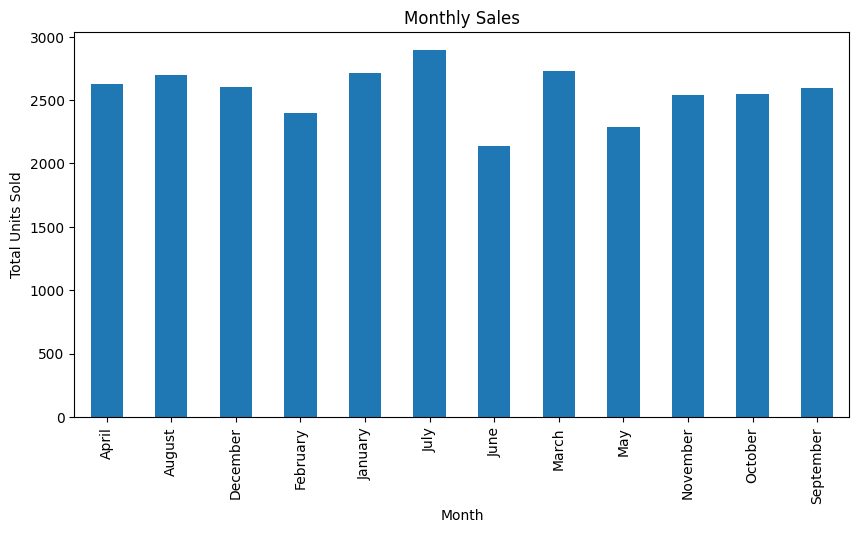

In [286]:
monthly_sales.plot(kind='bar', figsize=(10,5))
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Units Sold')
plt.show()

Weekdays Analysis

In [287]:
day_sales = df.groupby('Day_of_Week')['Units_Sold'].mean()
day_sales

,Units_Sold
Day_of_Week,
Friday,37.894231
Monday,41.523810
Saturday,52.019231
Sunday,49.567308
Thursday,36.750000
Tuesday,41.571429
Wednesday,35.759615


Season analysis

In [288]:
df.groupby('Season')['Units_Sold'].mean()

,Units_Sold
Season,
Autumn,42.203297
Spring,41.532609
Summer,42.032609
Winter,42.861111


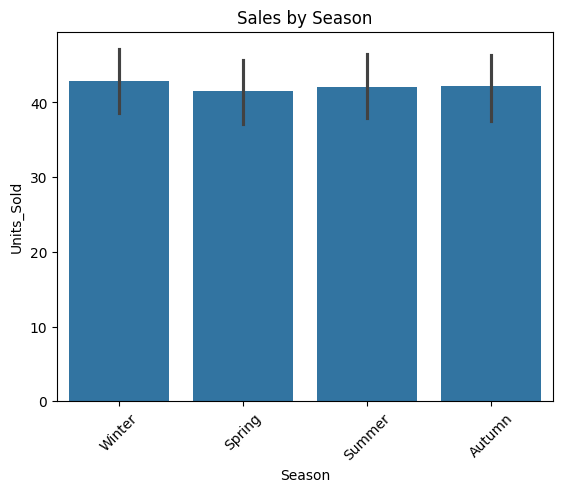

In [289]:
sns.barplot(data=df, x='Season', y='Units_Sold')
plt.title('Sales by Season')
plt.xticks(rotation=45)
plt.show()

Product analysis

In [290]:
product_sales = (
    df.groupby('Product_Name')['Units_Sold'].sum().sort_values(ascending=False)
)
product_sales.head(8)

,Units_Sold
Product_Name,
LED Desk Lamp,4191
Coffee Maker,4084
Running Shoes,4044
Notebook Pack,3964
Yoga Mat,3903
Wireless Mouse,3785
Office Chair,3756
Bluetooth Speaker,3045


Category analysis

In [291]:
category_sales = df.groupby('Category')['Units_Sold'].sum()
category_sales

,Units_Sold
Category,
Apparel,4044
Appliances,4084
Electronics,6830
Furniture,3756
Home,4191
Sports,3903
Stationery,3964


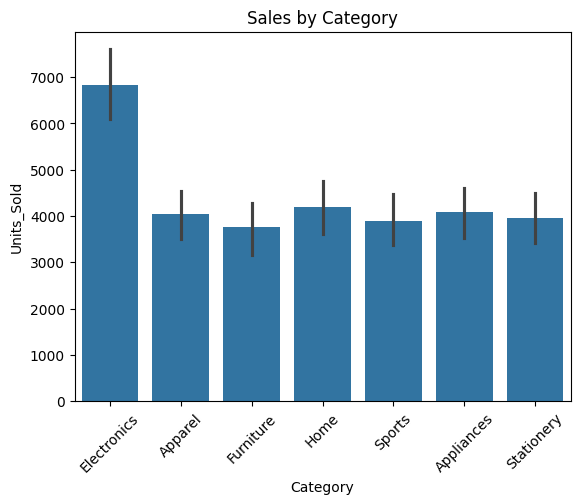

In [292]:
sns.barplot(
    data=df,
    x='Category',
    y='Units_Sold',
    estimator='sum'
)
plt.title('Sales by Category')
plt.xticks(rotation=45)
plt.show()

Sales channel analysis

In [293]:
df.groupby('Sales_Channel')['Units_Sold'].mean()

,Units_Sold
Sales_Channel,
In-Store,40.638298
Online,42.673554
Wholesale,43.063241


Customer segment analysis

In [294]:
df.groupby('Customer_Segment')['Units_Sold'].mean()

,Units_Sold
Customer_Segment,
Corporate,43.016260
Retail,40.807175
Wholesale,42.490421


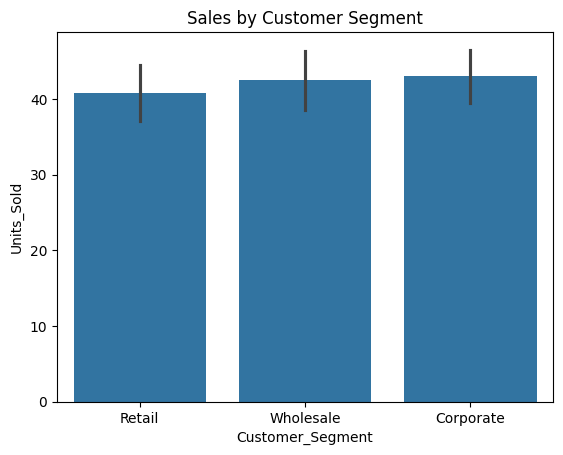

In [295]:
sns.barplot(
    data=df,
    x='Customer_Segment',
    y='Units_Sold'
)
plt.title('Sales by Customer Segment')
plt.show()

Price vs Units Sold

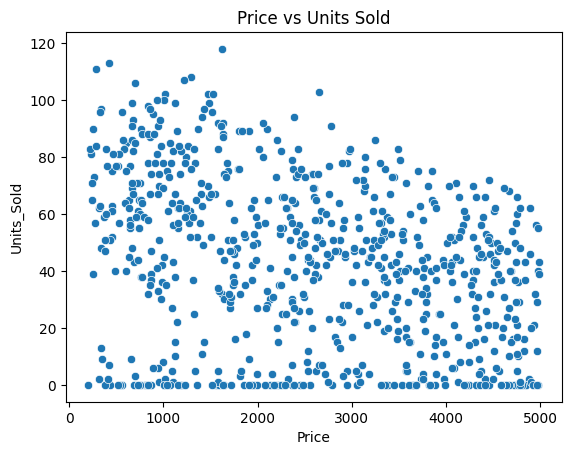

In [296]:
sns.scatterplot(
    data=df,
    x='Price',
    y='Units_Sold'
)
plt.title('Price vs Units Sold')
plt.show()

In [297]:
df[['Price', 'Units_Sold']].corr()

,Price,Units_Sold
Price,1.000000,-0.308165
Units_Sold,-0.308165,1.000000


Discount vs Units Sold

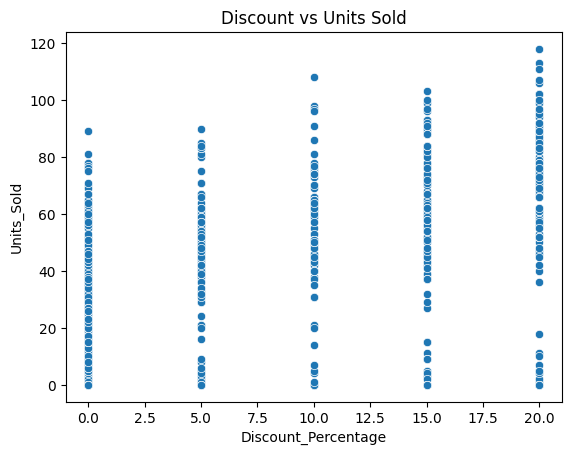

In [298]:
sns.scatterplot(
    data=df,
    x='Discount_Percentage',
    y='Units_Sold'
)
plt.title('Discount vs Units Sold')
plt.show()

Holiday analysis

In [299]:
df.groupby('Holiday_Flag')['Units_Sold'].mean()

,Units_Sold
Holiday_Flag,
0,42.041494
1,53.714286


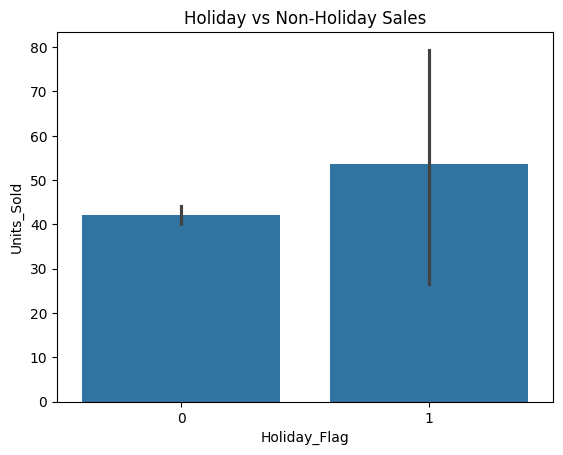

In [300]:
sns.barplot(
    data=df,
    x='Holiday_Flag',
    y='Units_Sold'
)
plt.title('Holiday vs Non-Holiday Sales')
plt.show()

Marketing spend analysis

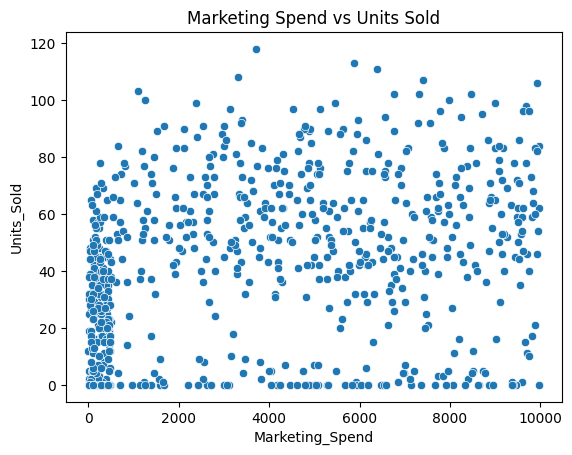

In [301]:
sns.scatterplot(
    data=df,
    x='Marketing_Spend',
    y='Units_Sold'
)
plt.title('Marketing Spend vs Units Sold')
plt.show()

In [302]:
df[['Marketing_Spend', 'Units_Sold']].corr()

,Marketing_Spend,Units_Sold
Marketing_Spend,1.000000,0.285701
Units_Sold,0.285701,1.000000


Revenue analysis

In [303]:
df['Revenue'].describe()

,Revenue
count,730.000000
mean,85193.486849
std,66840.589434
min,0.000000
25%,27826.057500
50%,73474.685000
75%,134810.962500
max,282047.830000


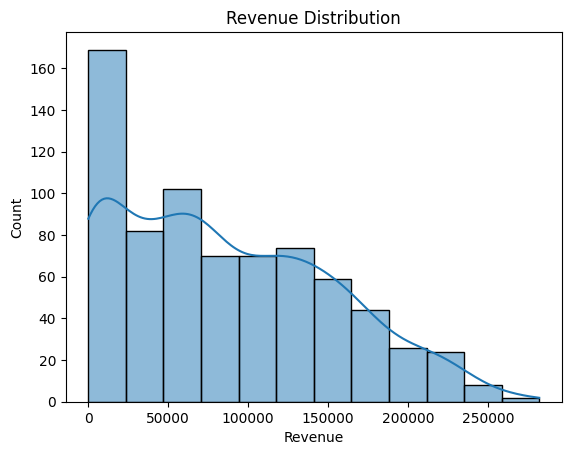

In [304]:
sns.histplot(df['Revenue'], kde=True)
plt.title('Revenue Distribution')
plt.show()

Price and revenue

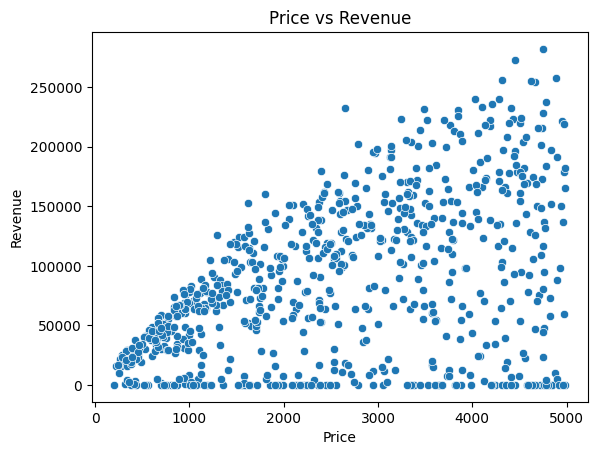

In [305]:
sns.scatterplot(
    data=df,
    x='Price',
    y='Revenue'
)
plt.title('Price vs Revenue')
plt.show()

Check unique values

In [306]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Row_ID : 730
Date : 730
Product_ID : 8
Product_Name : 8
Category : 7
Store_ID : 4
Store_Location : 4
Units_Sold : 109
Price : 730
Discount_Percentage : 5
Revenue : 638
Promotion_Flag : 2
Stock_Availability : 2
Day_of_Week : 7
Month : 12
Quarter : 4
Holiday_Flag : 2
Holiday_Name : 7
Is_Weekend : 2
Season : 4
Weather : 5
Local_Event_Flag : 2
Competitor_Price : 730
Economic_Indicator : 582
Sales_Channel : 3
Customer_Segment : 3
Marketing_Spend : 730


sales by product and date

In [307]:
df.groupby('Product_ID')['Date'].agg(['min', 'max', 'count'])

,min,max,count
Product_ID,,,
P001,2024-01-02,2025-12-28,88
P002,2024-01-01,2025-12-30,83
P003,2024-01-06,2025-12-27,90
P004,2024-01-15,2025-12-29,90
P005,2024-01-07,2025-12-25,97
P006,2024-01-03,2025-12-14,94
P007,2024-01-09,2025-12-15,93
P008,2024-01-13,2025-12-04,95


sales seasonal

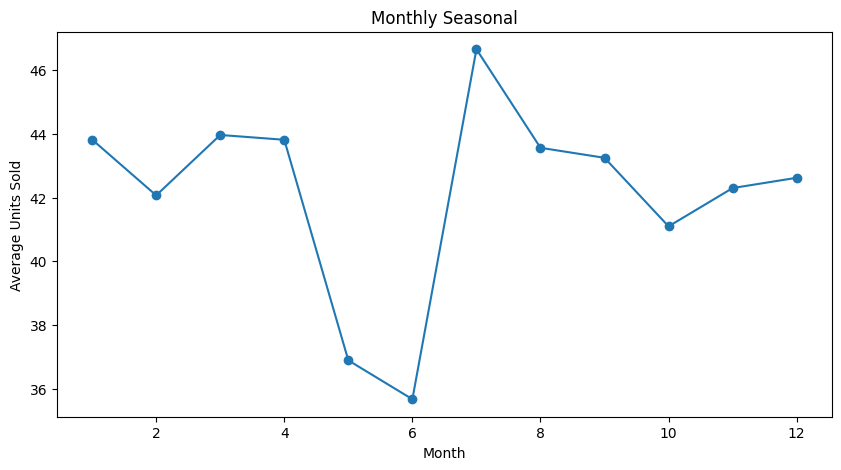

In [308]:
df['Month_Number'] = df['Date'].dt.month
monthly = df.groupby('Month_Number')['Units_Sold'].mean()
monthly.plot(figsize=(10,5), marker='o')
plt.title('Monthly Seasonal')
plt.xlabel('Month')
plt.ylabel('Average Units Sold')
plt.show()

Correlation matrix

In [309]:
corr_matrix = df[numeric_cols].corr()
units_corr = corr_matrix['Units_Sold'].sort_values(ascending=False)

print("Correlation with Units_Sold:")
print(units_corr)

Correlation with Units_Sold:
Units_Sold             1.000000
Stock_Availability     0.685237
Revenue                0.558440
Discount_Percentage    0.438107
Promotion_Flag         0.398375
Marketing_Spend        0.285701
Is_Weekend             0.187445
Local_Event_Flag       0.161955
Holiday_Flag           0.039097
Economic_Indicator    -0.021815
Row_ID                -0.081642
Price                 -0.308165
Competitor_Price      -0.310477
Name: Units_Sold, dtype: float64


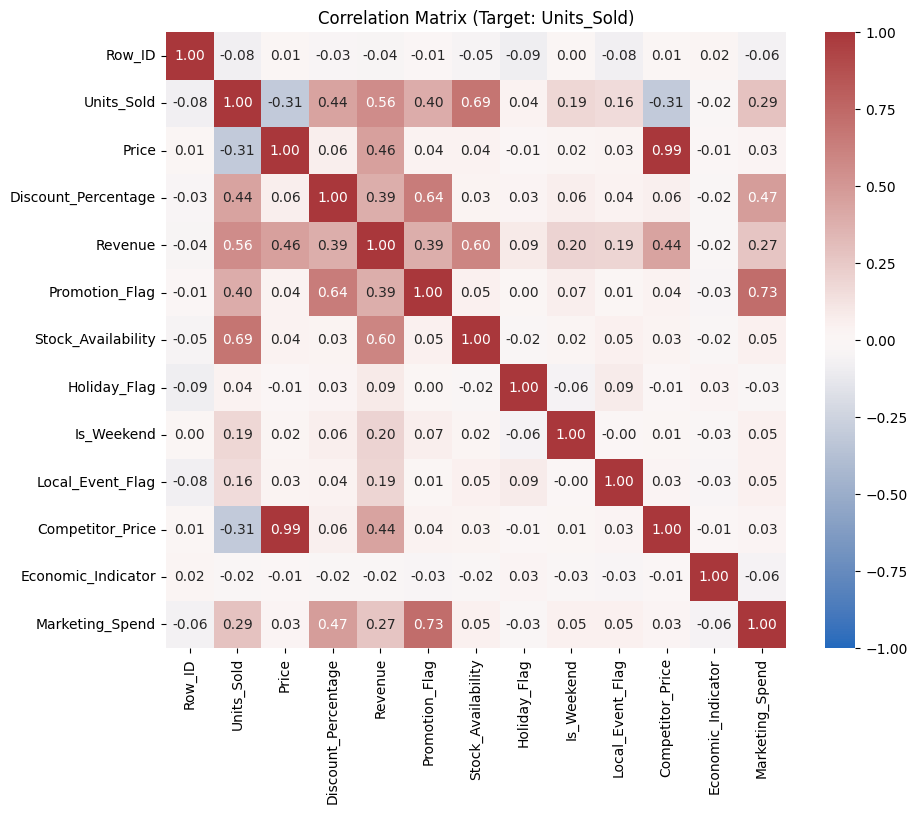

In [310]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='vlag', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix (Target: Units_Sold)')
plt.savefig('units_sold_correlation_matrix.png')
plt.show()

Time Series Analysis

In [311]:
df = df.sort_values('Date')
daily_sales = df.groupby('Date')['Units_Sold'].sum().reset_index()
print(daily_sales)

          Date  Units_Sold
0   2024-01-01          58
1   2024-01-02           0
2   2024-01-03          91
3   2024-01-04          57
4   2024-01-05          59
..         ...         ...
725 2025-12-26          52
726 2025-12-27          26
727 2025-12-28          57
728 2025-12-29          62
729 2025-12-30           0

[730 rows x 2 columns]


In [312]:
daily_sales.index.min()

0

In [313]:
daily_sales.index.max()

729

Visualize the time series

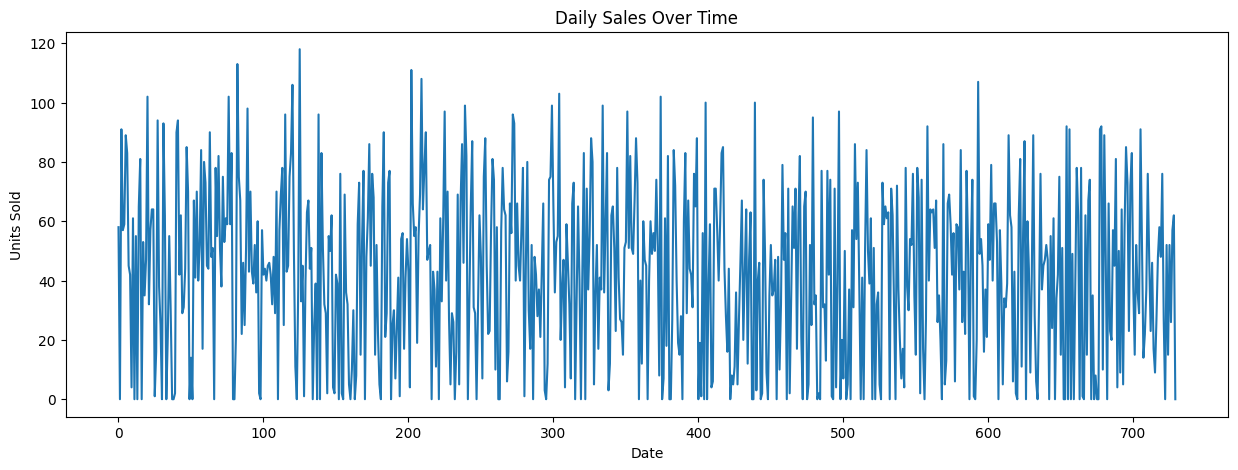

In [314]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales.index,
    daily_sales['Units_Sold']
)
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.show()

weekly seasonality

In [315]:
df.groupby('Day_of_Week')['Units_Sold'].mean()

,Units_Sold
Day_of_Week,
Friday,37.894231
Monday,41.523810
Saturday,52.019231
Sunday,49.567308
Thursday,36.750000
Tuesday,41.571429
Wednesday,35.759615



Lag Feature

In [316]:
df['Lag_1'] = (df.groupby('Product_ID')['Units_Sold'].shift(1))
df['Lag_7'] = (df.groupby('Product_ID')['Units_Sold'].shift(7))
df['Lag_14'] = (df.groupby('Product_ID')['Units_Sold'].shift(14))
df['Lag_30'] = (df.groupby('Product_ID')['Units_Sold'].shift(30))

In [317]:
print(df)

     Row_ID       Date Product_ID       Product_Name     Category Store_ID  \
0         1 2024-01-01       P002  Bluetooth Speaker  Electronics      S01   
1         2 2024-01-02       P001     Wireless Mouse  Electronics      S02   
2         3 2024-01-03       P006      Running Shoes      Apparel      S03   
3         4 2024-01-04       P001     Wireless Mouse  Electronics      S04   
4         5 2024-01-05       P002  Bluetooth Speaker  Electronics      S01   
..      ...        ...        ...                ...          ...      ...   
725     726 2025-12-26       P003       Office Chair    Furniture      S04   
726     727 2025-12-27       P003       Office Chair    Furniture      S01   
727     728 2025-12-28       P001     Wireless Mouse  Electronics      S01   
728     729 2025-12-29       P004      Notebook Pack   Stationery      S02   
729     730 2025-12-30       P002  Bluetooth Speaker  Electronics      S02   

    Store_Location  Units_Sold    Price  Discount_Percentage  .

In [318]:
df.shape

(730, 32)

rolling features

In [319]:
df['Rolling_7'] = (
    df.groupby('Product_ID')['Units_Sold']
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

df['Rolling_14'] = (
    df.groupby('Product_ID')['Units_Sold']
      .transform(lambda x: x.shift(1).rolling(14).mean())
)

df['Rolling_30'] = (
    df.groupby('Product_ID')['Units_Sold']
      .transform(lambda x: x.shift(1).rolling(30).mean())
)

In [320]:
df.shape

(730, 35)

In [321]:
import pandas as pd

df = pd.read_excel("sales_forecasting_master_dataset 2.xlsx")

df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter
df['Week'] = df['Date'].dt.isocalendar().week
df['Is_Weekend'] = (df['Day_of_Week'] >= 5).astype(int)

print(df[['Date', 'Year', 'Month', 'Day',
          'Day_of_Week', 'Quarter', 'Week',
          'Is_Weekend']].head(10))

        Date  Year  Month  Day  Day_of_Week  Quarter  Week  Is_Weekend
0 2024-01-01  2024      1    1            0        1     1           0
1 2024-01-02  2024      1    2            1        1     1           0
2 2024-01-03  2024      1    3            2        1     1           0
3 2024-01-04  2024      1    4            3        1     1           0
4 2024-01-05  2024      1    5            4        1     1           0
5 2024-01-06  2024      1    6            5        1     1           1
6 2024-01-07  2024      1    7            6        1     1           1
7 2024-01-08  2024      1    8            0        1     2           0
8 2024-01-09  2024      1    9            1        1     2           0
9 2024-01-10  2024      1   10            2        1     2           0


In [322]:
df.shape

(730, 30)

Encode categorical variables

In [323]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Product_ID',
        'Product_Name',
        'Category',
        'Store_ID',
        'Store_Location',
        'Day_of_Week',
        'Season',
        'Weather',
        'Sales_Channel',
        'Customer_Segment'
    ],
    drop_first=True
)
print(df_encoded)

     Row_ID       Date  Units_Sold    Price  Discount_Percentage    Revenue  \
0         1 2024-01-01          58  3759.44                    0  218047.52   
1         2 2024-01-02           0  3636.89                   15       0.00   
2         3 2024-01-03          91   946.30                   20   68890.64   
3         4 2024-01-04          57  2773.89                    5  150206.14   
4         5 2024-01-05          59  3374.06                   20  159255.63   
..      ...        ...         ...      ...                  ...        ...   
725     726 2025-12-26          52  4138.05                   20  172142.88   
726     727 2025-12-27          26  3422.68                    0   88989.68   
727     728 2025-12-28          57  2074.97                    0  118273.29   
728     729 2025-12-29          62   638.65                    5   37616.48   
729     730 2025-12-30           0  3675.26                    0       0.00   

     Promotion_Flag  Stock_Availability  Month  Qua

Aggregate all sales by date first:

In [324]:
daily = (
    df.groupby('Date')
      .agg({
          'Units_Sold': 'sum',
          'Marketing_Spend': 'sum',
          'Promotion_Flag': 'max',
          'Holiday_Flag': 'max',
          'Local_Event_Flag': 'max',
          'Economic_Indicator': 'mean'
      })
      .reset_index()
)
print(daily)

          Date  Units_Sold  Marketing_Spend  Promotion_Flag  Holiday_Flag  \
0   2024-01-01          58           109.32               0             1   
1   2024-01-02           0          7132.32               1             0   
2   2024-01-03          91          3012.95               1             0   
3   2024-01-04          57          2326.74               1             0   
4   2024-01-05          59          8424.05               1             0   
..         ...         ...              ...             ...           ...   
725 2025-12-26          52          7543.74               1             0   
726 2025-12-27          26           108.08               0             0   
727 2025-12-28          57          4059.12               1             0   
728 2025-12-29          62          9608.08               1             0   
729 2025-12-30           0          9376.11               1             0   

     Local_Event_Flag  Economic_Indicator  
0                   1          

Remove Unnecessary Features

In [325]:
columns_to_remove = [
    'Row_ID',
    'Revenue',
    'Holiday_Name'
]

df = df.drop(
    columns=columns_to_remove,
    errors='ignore'
)

In [326]:
df.shape

(730, 27)

In [327]:
print(df)

          Date Product_ID       Product_Name     Category Store_ID  \
0   2024-01-01       P002  Bluetooth Speaker  Electronics      S01   
1   2024-01-02       P001     Wireless Mouse  Electronics      S02   
2   2024-01-03       P006      Running Shoes      Apparel      S03   
3   2024-01-04       P001     Wireless Mouse  Electronics      S04   
4   2024-01-05       P002  Bluetooth Speaker  Electronics      S01   
..         ...        ...                ...          ...      ...   
725 2025-12-26       P003       Office Chair    Furniture      S04   
726 2025-12-27       P003       Office Chair    Furniture      S01   
727 2025-12-28       P001     Wireless Mouse  Electronics      S01   
728 2025-12-29       P004      Notebook Pack   Stationery      S02   
729 2025-12-30       P002  Bluetooth Speaker  Electronics      S02   

    Store_Location  Units_Sold    Price  Discount_Percentage  Promotion_Flag  \
0          Chennai          58  3759.44                    0               0   

Handle Missing Values Created by Lag/Rolling Features

In [328]:
missing_values = df.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ].sort_values(ascending=False)
)
print(missing_values)

Series([], dtype: int64)
Date                   0
Product_ID             0
Product_Name           0
Category               0
Store_ID               0
Store_Location         0
Units_Sold             0
Price                  0
Discount_Percentage    0
Promotion_Flag         0
Stock_Availability     0
Day_of_Week            0
Month                  0
Quarter                0
Holiday_Flag           0
Is_Weekend             0
Season                 0
Weather                0
Local_Event_Flag       0
Competitor_Price       0
Economic_Indicator     0
Sales_Channel          0
Customer_Segment       0
Marketing_Spend        0
Year                   0
Day                    0
Week                   0
dtype: int64


Remove rows with insufficient history

In [329]:
lag_rolling_cols = [
    'Lag_1',
    'Lag_7',
    'Lag_14',
    'Lag_30',
    'Rolling_7',
    'Rolling_14',
    'Rolling_30'
]

df = df.dropna().reset_index(drop=True)

In [330]:
print(df)

          Date Product_ID       Product_Name     Category Store_ID  \
0   2024-01-01       P002  Bluetooth Speaker  Electronics      S01   
1   2024-01-02       P001     Wireless Mouse  Electronics      S02   
2   2024-01-03       P006      Running Shoes      Apparel      S03   
3   2024-01-04       P001     Wireless Mouse  Electronics      S04   
4   2024-01-05       P002  Bluetooth Speaker  Electronics      S01   
..         ...        ...                ...          ...      ...   
725 2025-12-26       P003       Office Chair    Furniture      S04   
726 2025-12-27       P003       Office Chair    Furniture      S01   
727 2025-12-28       P001     Wireless Mouse  Electronics      S01   
728 2025-12-29       P004      Notebook Pack   Stationery      S02   
729 2025-12-30       P002  Bluetooth Speaker  Electronics      S02   

    Store_Location  Units_Sold    Price  Discount_Percentage  Promotion_Flag  \
0          Chennai          58  3759.44                    0               0   

Final Missing Value Check

In [331]:
print("Remaining missing values:")
print(df.isnull().sum().sum())

print("Final dataset shape:")
print(df.shape)

Remaining missing values:
0
Final dataset shape:
(730, 27)


In [332]:
# Remove rows having ANY missing value in the entire dataset
df = df.dropna().reset_index(drop=True)

print("Remaining missing values:", df.isnull().sum().sum())
print("Final dataset shape:", df.shape)

Remaining missing values: 0
Final dataset shape: (730, 27)


Feature & Target Separation

In [333]:
# Target
y = df['Units_Sold']

# Features
X = df.drop(columns=['Units_Sold'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (730, 26)
y shape: (730,)


Check the data types

In [334]:
print(X.dtypes)

Date                   datetime64[ns]
Product_ID                     object
Product_Name                   object
Category                       object
Store_ID                       object
Store_Location                 object
Price                         float64
Discount_Percentage             int64
Promotion_Flag                  int64
Stock_Availability              int64
Day_of_Week                     int32
Month                           int32
Quarter                         int32
Holiday_Flag                    int64
Is_Weekend                      int64
Season                         object
Weather                        object
Local_Event_Flag                int64
Competitor_Price              float64
Economic_Indicator            float64
Sales_Channel                  object
Customer_Segment               object
Marketing_Spend               float64
Year                            int32
Day                             int32
Week                           UInt32
dtype: objec

Check correlation with the target

In [335]:
correlation = df.corr(numeric_only=True)['Units_Sold'].sort_values(
    ascending=False
)

print(correlation)

Units_Sold             1.000000
Stock_Availability     0.685237
Discount_Percentage    0.438107
Promotion_Flag         0.398375
Marketing_Spend        0.285701
Is_Weekend             0.187445
Local_Event_Flag       0.161955
Day_of_Week            0.115434
Day                    0.055451
Holiday_Flag           0.039097
Week                   0.010588
Quarter                0.006972
Month                 -0.001412
Economic_Indicator    -0.021815
Year                  -0.096126
Price                 -0.308165
Competitor_Price      -0.310477
Name: Units_Sold, dtype: float64


Check feature-to-feature correlation:

In [336]:
corr_matrix = X.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_features = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Highly correlated features:")
print(high_corr_features)

Highly correlated features:
['Quarter', 'Competitor_Price', 'Week']


Check constant features

In [337]:
constant_features = [
    column
    for column in X.columns
    if X[column].nunique() <= 1
]

print("Constant features:")
print(constant_features)

Constant features:
[]


chronological Train/Test Split.

In [338]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (584, 26)
Testing data: (146, 26)


Verify the split

In [339]:
print("Training period:")
print(df['Product_ID'].iloc[:split_index].min())
print(df['Product_ID'].iloc[:split_index].max())

print("\nTesting period:")
print(df['Product_ID'].iloc[split_index:].min())
print(df['Product_ID'].iloc[split_index:].max())

Training period:
P001
P008

Testing period:
P001
P008


In [340]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Check the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (584, 26)
X_test : (146, 26)
y_train: (584,)
y_test : (146,)


Start with a baseline

In [341]:
y_pred_baseline = X_test['Discount_Percentage']

print(y_pred_baseline.head())

584     0
585    10
586     0
587     0
588    10
Name: Discount_Percentage, dtype: int64


In [342]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred_baseline)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_baseline)
)

print("Baseline MAE:", mae)
print("Baseline RMSE:", rmse)

Baseline MAE: 34.78767123287671
Baseline RMSE: 41.7250458604277


Model Evalution

In [343]:
!pip install prophet xgboost tensorflow

In [344]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

from prophet import Prophet

from xgboost import XGBRegressor
import xgboost as xgb

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

Arima

In [345]:
# Create daily sales series
arima_data = (
    df.groupby('Date')['Units_Sold']
      .sum()
      .reset_index()
)

arima_data['Date'] = pd.to_datetime(arima_data['Date'])

arima_data = arima_data.sort_values('Date')

arima_data = arima_data.set_index('Date')

print(arima_data.head())

            Units_Sold
Date                  
2024-01-01          58
2024-01-02           0
2024-01-03          91
2024-01-04          57
2024-01-05          59


Chronological split

In [346]:
split_index = int(len(arima_data) * 0.80)

arima_train = arima_data['Units_Sold'].iloc[:split_index]
arima_test = arima_data['Units_Sold'].iloc[split_index:]

print("ARIMA train:", len(arima_train))
print("ARIMA test:", len(arima_test))

ARIMA train: 584
ARIMA test: 146


Train ARIMA

In [347]:
arima_model = ARIMA(
    arima_train,
    order=(1, 1, 1)
)

arima_result = arima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Predict

In [348]:
arima_pred = arima_result.forecast(
    steps=len(arima_test)
)

arima_pred = np.array(arima_pred)

Evaluate

In [349]:
arima_mae = mean_absolute_error(
    arima_test,
    arima_pred
)

arima_rmse = np.sqrt(
    mean_squared_error(
        arima_test,
        arima_pred
    )
)

print("ARIMA MAE :", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE : 24.57866978987789
ARIMA RMSE: 28.792966277836314


Prophet(Create dataset)

In [350]:
prophet_data = (
    df.groupby('Date')['Units_Sold']
      .sum()
      .reset_index()
)

prophet_data.columns = ['ds', 'y']

prophet_data['ds'] = pd.to_datetime(
    prophet_data['ds']
)

prophet_data = prophet_data.sort_values('ds')

Train/test split

In [351]:
split_index = int(len(prophet_data) * 0.80)

prophet_train = prophet_data.iloc[:split_index]
prophet_test = prophet_data.iloc[split_index:]

Train Prophet

In [352]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

Predict

In [353]:
prophet_forecast = prophet_model.predict(
    prophet_test[['ds']]
)

prophet_pred = prophet_forecast['yhat'].values

Evaluate

In [354]:
prophet_mae = mean_absolute_error(
    prophet_test['y'],
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test['y'],
        prophet_pred
    )
)

print("Prophet MAE :", prophet_mae)
print("Prophet RMSE:", prophet_rmse)

Prophet MAE : 24.522257692665928
Prophet RMSE: 28.727008974641734


LSTM

In [355]:
lstm_data = (
    df.groupby('Date')['Units_Sold']
      .sum()
      .reset_index()
)

lstm_data = lstm_data.sort_values('Date')

sales = lstm_data['Units_Sold'].values.reshape(-1, 1)

Scale the data

In [369]:
scaler = MinMaxScaler()
sales_scaled = scaler.fit_transform(sales)

Create sequences

In [370]:
lookback = 30

X_lstm = []
y_lstm = []

for i in range(
    lookback,
    len(sales_scaled)
):

    X_lstm.append(
        sales_scaled[i-lookback:i, 0]
    )

    y_lstm.append(
        sales_scaled[i, 0]
    )

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

Reshape for LSTM

In [371]:
X_lstm = X_lstm.reshape(
    X_lstm.shape[0],
    X_lstm.shape[1],
    1
)

Chronological LSTM split

In [372]:
split_index = int(
    len(X_lstm) * 0.80
)

X_lstm_train = X_lstm[:split_index]
X_lstm_test = X_lstm[split_index:]

y_lstm_train = y_lstm[:split_index]
y_lstm_test = y_lstm[split_index:]

print(
    X_lstm_train.shape,
    X_lstm_test.shape
)

(560, 30, 1) (140, 30, 1)


Build LSTM model

In [373]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_lstm_train.shape[1],
            1
        )
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(
    LSTM(32)
)

lstm_model.add(Dropout(0.2))

lstm_model.add(
    Dense(1)
)

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Train LSTM

In [374]:
history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    shuffle=False,
    verbose=1
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0826 - val_loss: 0.0526
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0653 - val_loss: 0.0531
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0637 - val_loss: 0.0533
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0651 - val_loss: 0.0541
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0662 - val_loss: 0.0537
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0633 - val_loss: 0.0525
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0656 - val_loss: 0.0541
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0645 - val_loss: 0.0539
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0644 - val_loss: 0.0554
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0644 - val_loss: 0.0537
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0641 - val_loss: 0.0538
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0

LSTM prediction

In [375]:
lstm_pred_scaled = lstm_model.predict(
    X_lstm_test
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


Convert predictions back to the original sales scale

In [376]:
lstm_pred = scaler.inverse_transform(
    lstm_pred_scaled
).flatten()

lstm_actual = scaler.inverse_transform(
    y_lstm_test.reshape(-1, 1)
).flatten()

Evaluate LSTM

In [377]:
lstm_mae = mean_absolute_error(
    lstm_actual,
    lstm_pred
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        lstm_actual,
        lstm_pred
    )
)

print("LSTM MAE :", lstm_mae)
print("LSTM RMSE:", lstm_rmse)

LSTM MAE : 24.595175388881138
LSTM RMSE: 28.909041375240122


XGBoost

In [356]:
!pip install xgboost

Removing Date columne

In [357]:
columns_to_remove = [
    'Date'
]

df = df.drop(
    columns=columns_to_remove,
    errors='ignore'
)

In [358]:
df.shape

(730, 26)

Creating X and Y

In [359]:
# Target
y = df['Units_Sold']

# Features
X = df.drop(columns=['Units_Sold'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (730, 25)
y shape: (730,)


Find categorical columns

In [360]:
categorical_cols = X.select_dtypes(
    include=['object']
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['Product_ID', 'Product_Name', 'Category', 'Store_ID', 'Store_Location', 'Season', 'Weather', 'Sales_Channel', 'Customer_Segment']


One-hot encode categorical columns

In [361]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

Convert boolean columns to integers

In [362]:
X = X.astype(float)

Check for remaining object columns

In [363]:
print("\nObject columns remaining:")
print(X.select_dtypes(include=['object']).columns.tolist())


Object columns remaining:
[]


chronological split

In [364]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (584, 53)
X_test : (146, 53)
y_train: (584,)
y_test : (146,)


In [365]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

Predict

In [366]:
xgb_pred = xgb_model.predict(X_test)

Evaluate

In [367]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

print("XGBoost MAE :", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE : 6.99425745010376
XGBoost RMSE: 8.831364346227614


Compare all four models

In [378]:
results = pd.DataFrame({
    'Model': [
        'ARIMA',
        'Prophet',
        'XGBoost',
        'LSTM'
    ],

    'MAE': [
        arima_mae,
        prophet_mae,
        xgb_mae,
        lstm_mae
    ],

    'RMSE': [
        arima_rmse,
        prophet_rmse,
        xgb_rmse,
        lstm_rmse
    ]
})

results = results.sort_values(
    'RMSE'
).reset_index(drop=True)

print(results)

     Model        MAE       RMSE
0  XGBoost   6.994257   8.831364
1  Prophet  24.522258  28.727009
2    ARIMA  24.578670  28.792966
3     LSTM  24.595175  28.909041


Compare predictions visually

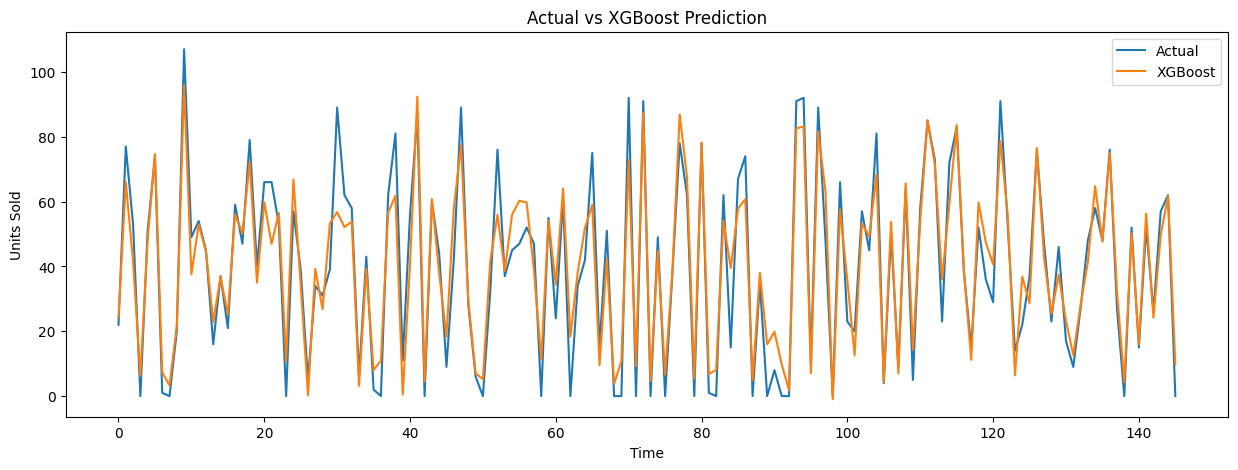

In [379]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    xgb_pred,
    label='XGBoost'
)

plt.title('Actual vs XGBoost Prediction')
plt.xlabel('Time')
plt.ylabel('Units Sold')

plt.legend()
plt.show()

For LSTM

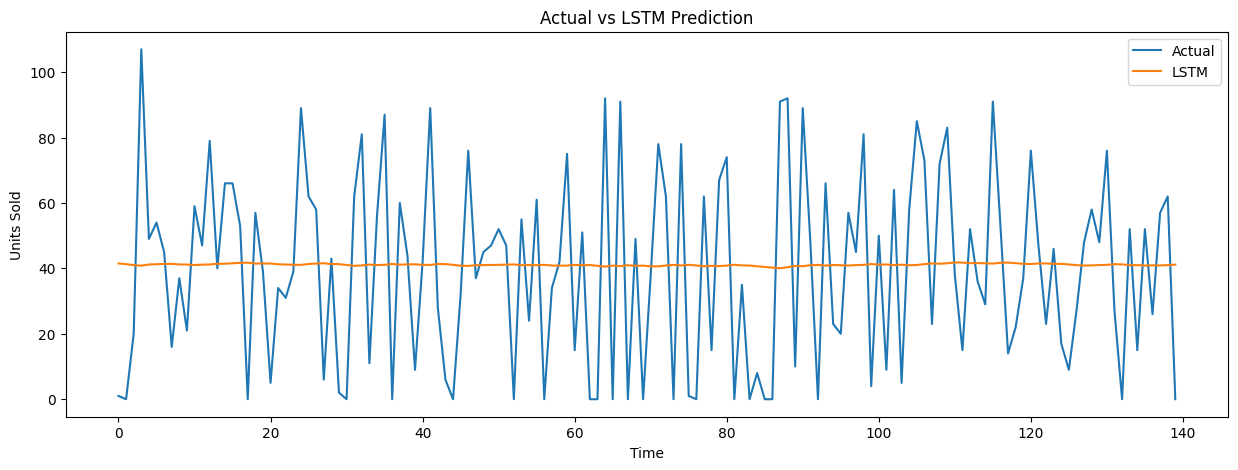

In [381]:
plt.figure(figsize=(15, 5))

plt.plot(
    lstm_actual,
    label='Actual'
)

plt.plot(
    lstm_pred,
    label='LSTM'
)

plt.title('Actual vs LSTM Prediction')
plt.xlabel('Time')
plt.ylabel('Units Sold')

plt.legend()
plt.show()